**Serie temporal de caudales medios con resolución diaria**

Extraer datos de Excel


In [1]:
import openpyxl
import numpy as np
web = openpyxl.load_workbook("./Datos/Cuenca 5702001 - Rio Volcan En Queltehues (Lat. -33.81, Lon. -70.21).xlsx")
print(web.sheetnames) #Ver la hoja donde esta la informacion

['Serie']


In [2]:
import pandas as pd
Q = pd.read_excel(io = "./Datos/Cuenca 5702001 - Rio Volcan En Queltehues (Lat. -33.81, Lon. -70.21).xlsx", sheet_name= "Serie" ,header=0, names = None, index_col = None,engine= "openpyxl")
Qf = Q.fillna(0) #rellenar las celdas vacías con ceros
#Q.head() #primeras filas 
#Q.tail() #ultimas filas
#Q.describe() #estadística descriptiva

In [3]:
fecha = pd.to_datetime(pd.DataFrame({'year': Qf['agno'], 'month': Qf['mes'], 'day': Qf['dia']}))
fecha.head()

0   1900-01-01
1   1900-01-02
2   1900-01-03
3   1900-01-04
4   1900-01-05
dtype: datetime64[ns]

In [4]:
New_table = pd.Series(Qf['valor'].values,index=fecha)
New_Q3 = New_table.replace(0,np.nan)
New_Q = New_table.resample('Y').max() #maximos de cada año
New_Q2 = New_Q.replace(0,np.nan) #remplazar 0 por nan
#New_Q2.tail() #ultimas filas
#print(New_table)


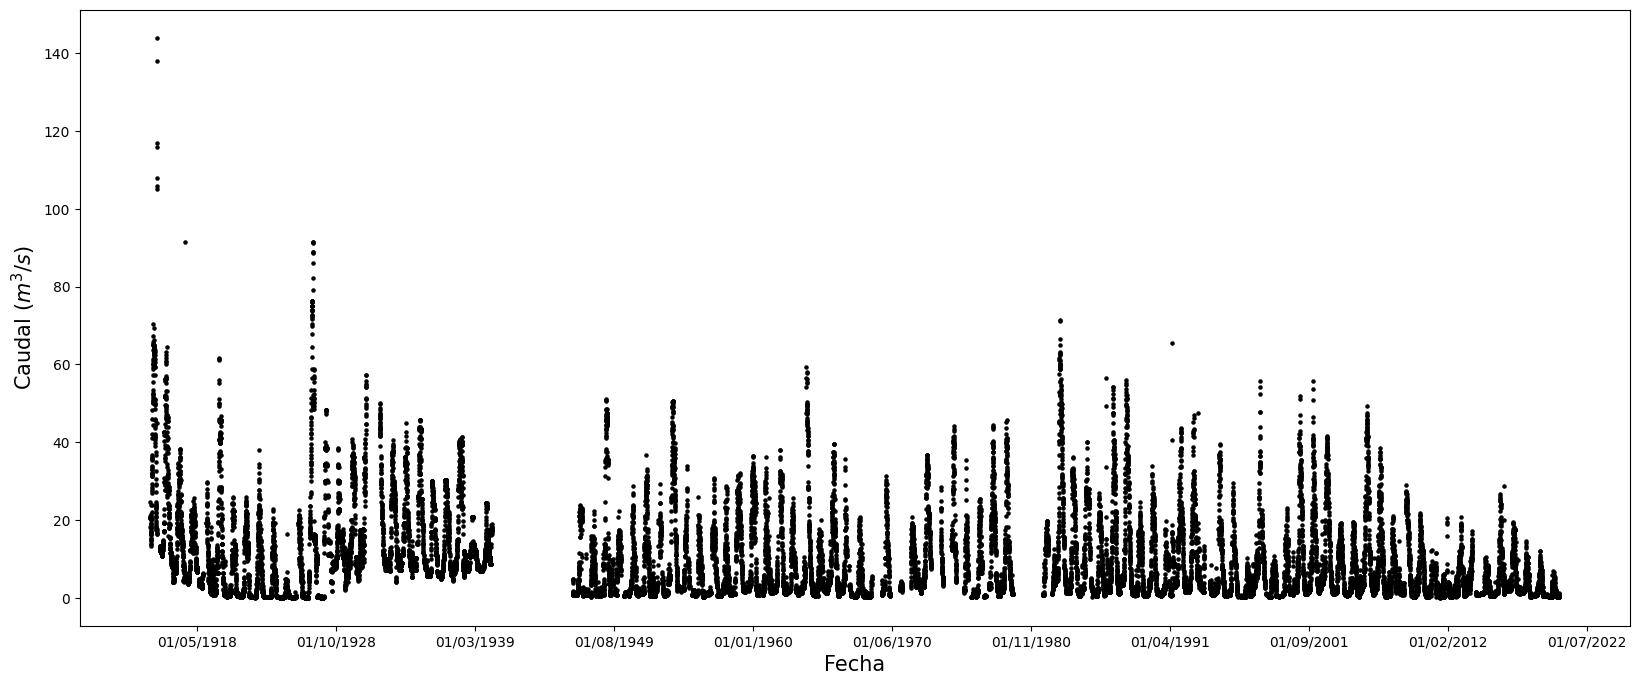

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ad = plt.subplots(figsize=(20, 8)) #tamaño grafico
#ad = New_table.plot(kind="line", x="valor" ,y="fecha", c="k", linestyle='-')
ax = plt.scatter(New_Q3.index, New_Q3, s=5, c='k')
plt.xlabel("Fecha", fontsize=15) #tamaño letra eje x
plt.ylabel("Caudal $(m^{3}/s)$", fontsize=15) #tamaño letra eje y
#plt.title("Caudales medios con resolución diaria en estación fluviométrica Río Volcán En Queltehues, desde 1900 hasta 2021", fontsize=18) #descripcion
ad.xaxis.set_major_locator(mdates.MonthLocator(interval=125))
ad.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
plt.show()

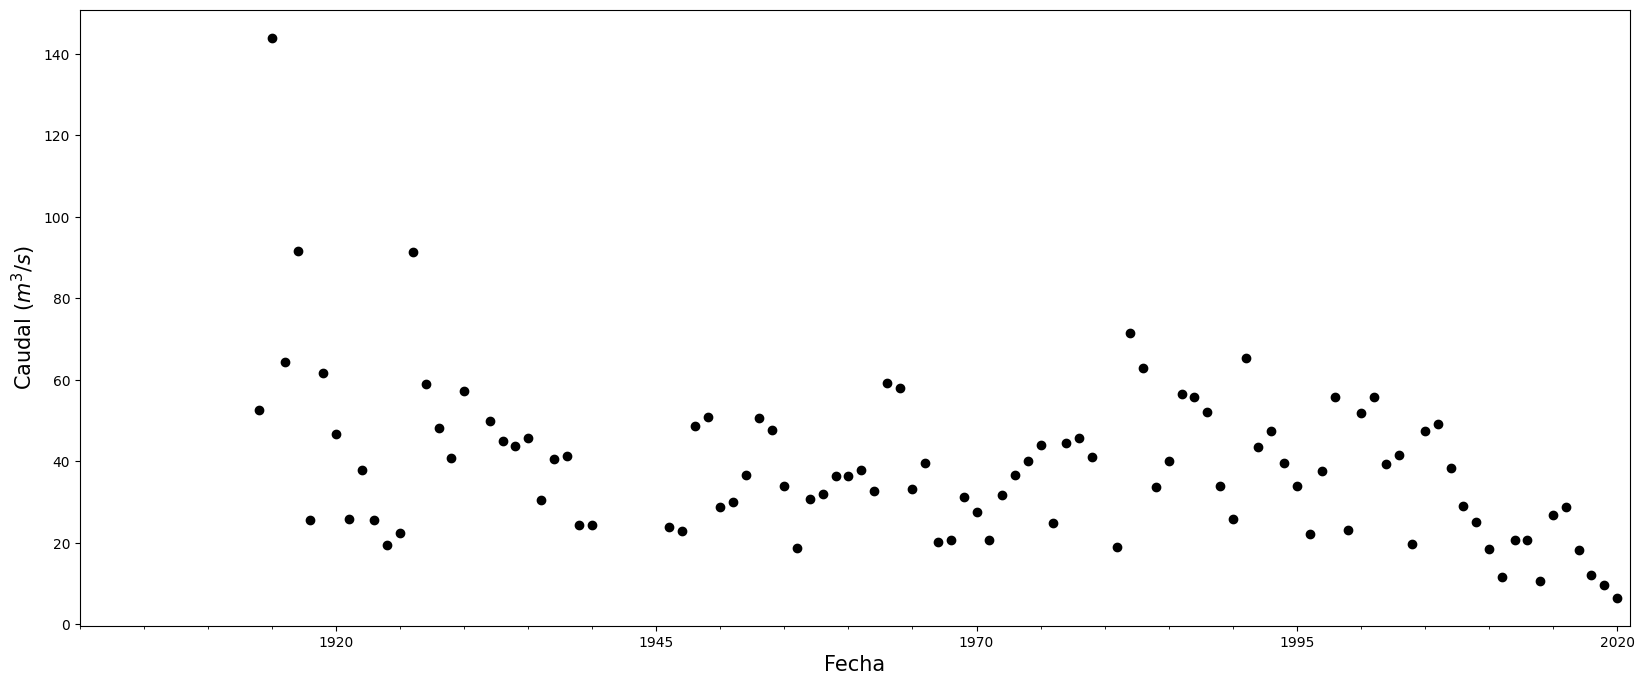

In [6]:
fig, ad = plt.subplots(figsize=(20, 8)) #tamaño grafico
ad = New_Q2.plot(kind="line", x="valor" ,y="fecha", marker="o", c="k", linestyle='')
#ax = plt.scatter(New_Q2.index, New_Q2, s=30, c='k')
plt.xlabel("Fecha", fontsize=15) #tamaño letra eje x
plt.ylabel("Caudal $(m^{3}/s)$", fontsize=15) #tamaño letra eje y
#plt.title("Caudales Máximo Anuales en estación fluviométrica Río Volcán En Queltehues, desde 1914 hasta 2020", fontsize=20)
#ad.xaxis.set_major_locator(mdates.MonthLocator(interval=48))
#ad.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

In [7]:
Q_Max = New_Q2.values
print(Q_Max) #todos los valores maximos de caudal

[    nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan  52.6   144.     64.4    91.6
  25.7    61.6    46.7    25.8    37.9    25.5    19.4    22.5    91.4
  58.9    48.3    40.9    57.3       nan  50.     44.9    43.9    45.8
  30.4    40.7    41.4    24.4    24.4       nan     nan     nan     nan
     nan  23.9    23.     48.6    51.     28.8    30.     36.6    50.6
  47.7    33.9    18.8    30.7    32.     36.5    36.3    38.     32.7
  59.3    58.1    33.3    39.6    20.2    20.7    31.2    27.5    20.8
  31.7    36.7    40.1    44.1    24.8    44.5    45.7    41.2       nan
  19.1    71.5    63.     33.7    40.1    56.5    55.9    52.1    34.
  25.8    65.4    43.6    47.5    39.6    33.9    22.1    37.7    55.7
  23.1    51.8    55.8    39.3    41.6    19.6    47.4    49.2    38.5
  29.     25.     18.4    11.6    20.6    20.7    10.6    26.8    28.7
  18.2    12.1     9.58    6.534     nan]


In [8]:
Data = pd.DataFrame(Q_Max, columns=["Caudales Max Anuales"]) 
New_Data = Data.tail(76) 
New_Data.to_excel("./Datos/Caudales Max Anuales.xlsx", index=True)
#print(New_Data)
Q1 = New_Data.values
#print(Q1)
Q2 = np.squeeze(Q1.tolist())
print(Q2) #todos los valores maximos de caudal desde 1945
#cta=len(Q2)
#print(cta)

[23.9   23.    48.6   51.    28.8   30.    36.6   50.6   47.7   33.9
 18.8   30.7   32.    36.5   36.3   38.    32.7   59.3   58.1   33.3
 39.6   20.2   20.7   31.2   27.5   20.8   31.7   36.7   40.1   44.1
 24.8   44.5   45.7   41.2      nan 19.1   71.5   63.    33.7   40.1
 56.5   55.9   52.1   34.    25.8   65.4   43.6   47.5   39.6   33.9
 22.1   37.7   55.7   23.1   51.8   55.8   39.3   41.6   19.6   47.4
 49.2   38.5   29.    25.    18.4   11.6   20.6   20.7   10.6   26.8
 28.7   18.2   12.1    9.58   6.534    nan]


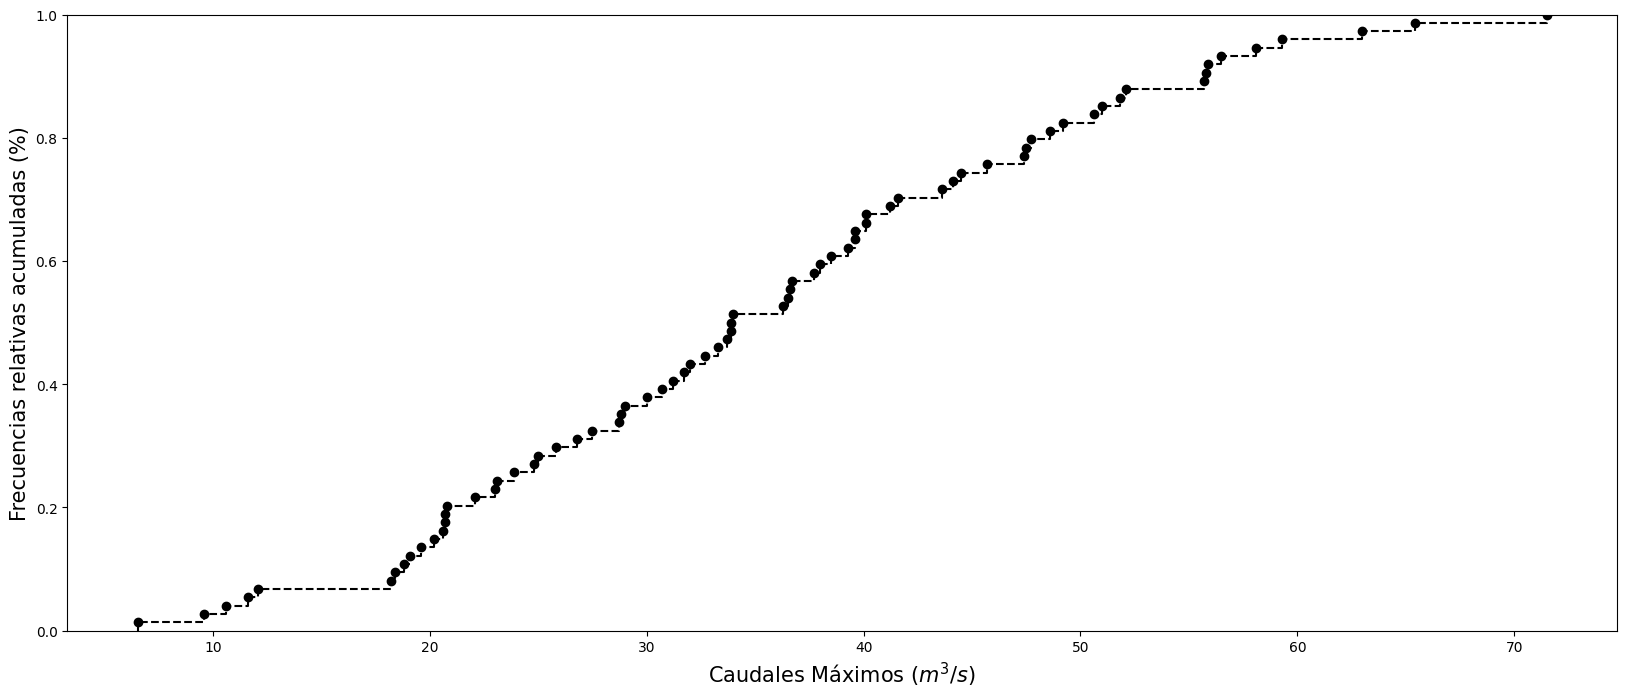

In [9]:
#Distribucion acumulada empírica EDCF
import seaborn as sns
fig, ax = plt.subplots(figsize=(20, 8)) #tamaño grafico
ax = sns.ecdfplot(data=New_Data.tail(76), x="Caudales Max Anuales", marker='o', c="k", linestyle='--')
#plt.title("Función de distribución empírica de caudales máximos anuales en estación fluviométrica Río Volcán En Queltehues, desde 1946 hasta 2020", fontsize=15)
plt.xlabel("Caudales Máximos $(m^{3}/s)$", fontsize=15) #tamaño letra eje x
plt.ylabel("Frecuencias relativas acumuladas (%)", fontsize=15) #tamaño letra eje y
plt.show()